# 고령인구 10만명당 노인복지시설 · 요양병원 수 상관관계 분석

**3조 "지역별 의료 인프라 격차 분석" — 고령화 파트**

기존 분석(고령인구비율 vs 노인복지관 수)에 이어, 아래 두 지표를 추가로 확인한다.

1. 고령인구비율 vs **고령인구 10만명당 노인복지시설 수** (경로당·노인복지관 등 시설 합계, 규모보정)
2. 고령인구비율 vs **고령인구 10만명당 요양병원 수** (건강보험심사평가원, KOSIS Open API `DT_MIRE01`, 2024년 4분기 기준)

절대량이 아닌 "고령인구 10만명당"으로 정규화해, 인구 규모가 큰 지역(경기·서울 등)이
시설 수도 단순히 많아지는 규모 효과를 제거한 뒤 상관관계를 본다.

데이터 출처: `data/aging/processed/aging_master.csv`
(생성: `python -m src.aging.preprocess.preprocess_aging`)

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# 프로젝트 루트 찾기 (이 노트북은 notebooks/aging/ 에 위치)
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "data" / "aging").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

from src.aging.analysis.correlation import interpret  # noqa: E402

MASTER_PATH = PROJECT_ROOT / "data" / "aging" / "processed" / "aging_master.csv"
master = pd.read_csv(MASTER_PATH)
master.head()

,시도,기준연도,총인구수,고령인구수_65세이상,고령인구비율,노인복지관수,경로당수,노인복지시설_합계,요양병원수,인구10만명당_노인복지관수,고령인구1만명당_노인복지관수,인구10만명당_경로당수,고령인구10만명당_노인복지시설수,고령인구10만명당_요양병원수
0,전라남도,2024,1788819,486492,27.20,33,9275,10269,79,1.84,0.68,518.50,2110.83,16.24
1,경상북도,2024,2531384,659227,26.04,23,8090,9186,103,0.91,0.35,319.59,1393.45,15.62
2,강원특별자치도,2024,1517766,384970,25.36,17,3350,4149,32,1.12,0.44,220.72,1077.75,8.31
3,전북특별자치도,2024,1738690,439263,25.26,32,6880,7914,74,1.84,0.73,395.70,1801.65,16.85
4,부산광역시,2024,3266598,780576,23.90,34,2423,3424,160,1.04,0.44,74.18,438.65,20.50


In [2]:
# ── 한글 폰트 설정 (Windows 기본 맑은 고딕 — 없으면 각 OS의 한글 폰트로 교체) ──
import matplotlib.font_manager as fm

for _candidate in ["Malgun Gothic", "AppleGothic", "NanumGothic"]:
    if any(_candidate == f.name for f in fm.fontManager.ttflist):
        plt.rcParams["font.family"] = _candidate
        break
plt.rcParams["axes.unicode_minus"] = False

# ── dataviz 스타일: 단일 계열 sequential 강조색 + 얇은 마크 (Streamlit 대시보드와 동일 톤) ──
ACCENT = "#2563eb"
TREND_COLOR = "#94a3b8"
GRID_COLOR = "#e2e8f0"


def scatter_with_corr(df: pd.DataFrame, x_col: str, y_col: str, x_label: str, y_label: str, title: str):
    x = df[x_col].to_numpy(dtype=float)
    y = df[y_col].to_numpy(dtype=float)

    pearson_r, pearson_p = stats.pearsonr(x, y)
    spearman_r, spearman_p = stats.spearmanr(x, y)
    slope, intercept = np.polyfit(x, y, 1)

    fig, ax = plt.subplots(figsize=(8, 6), dpi=110)

    # 추세선 (OLS)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, slope * x_line + intercept, color=TREND_COLOR, linewidth=2, zorder=1)

    # 산점 (단일 계열 = 단색, 얇은 흰 테두리로 겹침 구분)
    ax.scatter(x, y, s=90, color=ACCENT, edgecolor="white", linewidth=1.2, zorder=2)

    # 시도 라벨 (17개 포인트 전부 직접 라벨링 — 범례 불필요)
    for xi, yi, name in zip(x, y, df["시도"]):
        ax.annotate(name, (xi, yi), textcoords="offset points", xytext=(6, 5), fontsize=8, color="#334155")

    ax.set_xlabel(x_label, fontsize=11)
    ax.set_ylabel(y_label, fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.grid(True, color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    stat_text = (
        f"Pearson r = {pearson_r:.3f} (p = {pearson_p:.4f})\n"
        f"Spearman ρ = {spearman_r:.3f} (p = {spearman_p:.4f})\n"
        f"n = {len(df)} · {interpret(pearson_r)}"
    )
    ax.text(
        0.02, 0.98, stat_text, transform=ax.transAxes, fontsize=9.5,
        verticalalignment="top", color="#1e293b",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor=GRID_COLOR),
    )

    plt.tight_layout()
    plt.show()

    return {
        "x": x_col, "y": y_col, "pearson_r": round(pearson_r, 3), "pearson_p": round(pearson_p, 4),
        "spearman_r": round(spearman_r, 3), "spearman_p": round(spearman_p, 4), "n": len(df),
    }

## 1) 고령인구비율 vs 고령인구 10만명당 노인복지시설 수

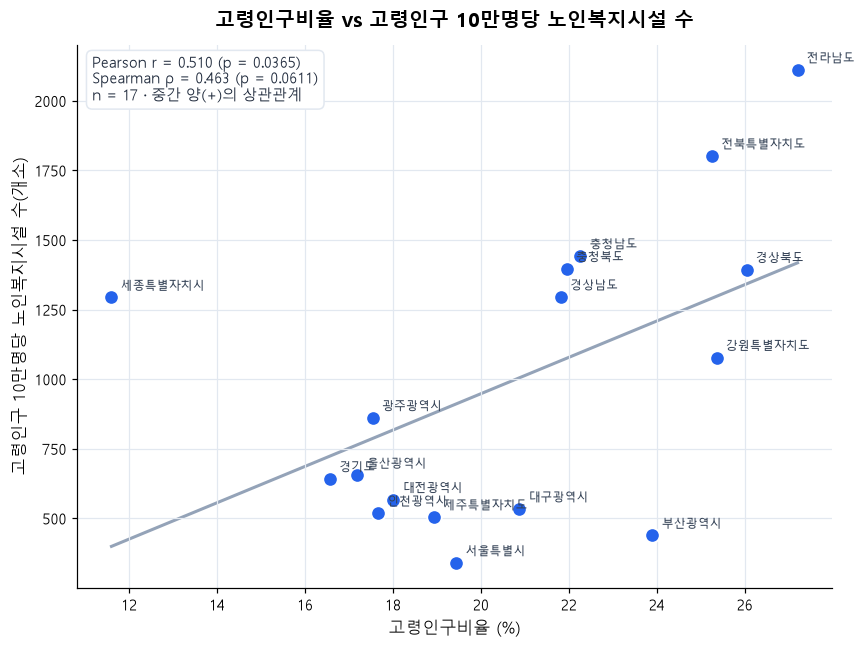

{'x': '고령인구비율',
 'y': '고령인구10만명당_노인복지시설수',
 'pearson_r': np.float64(0.51),
 'pearson_p': np.float64(0.0365),
 'spearman_r': np.float64(0.463),
 'spearman_p': np.float64(0.0611),
 'n': 17}

In [3]:
result_1 = scatter_with_corr(
    master,
    x_col="고령인구비율", y_col="고령인구10만명당_노인복지시설수",
    x_label="고령인구비율 (%)", y_label="고령인구 10만명당 노인복지시설 수(개소)",
    title="고령인구비율 vs 고령인구 10만명당 노인복지시설 수",
)
result_1

## 2) 고령인구비율 vs 고령인구 10만명당 요양병원 수

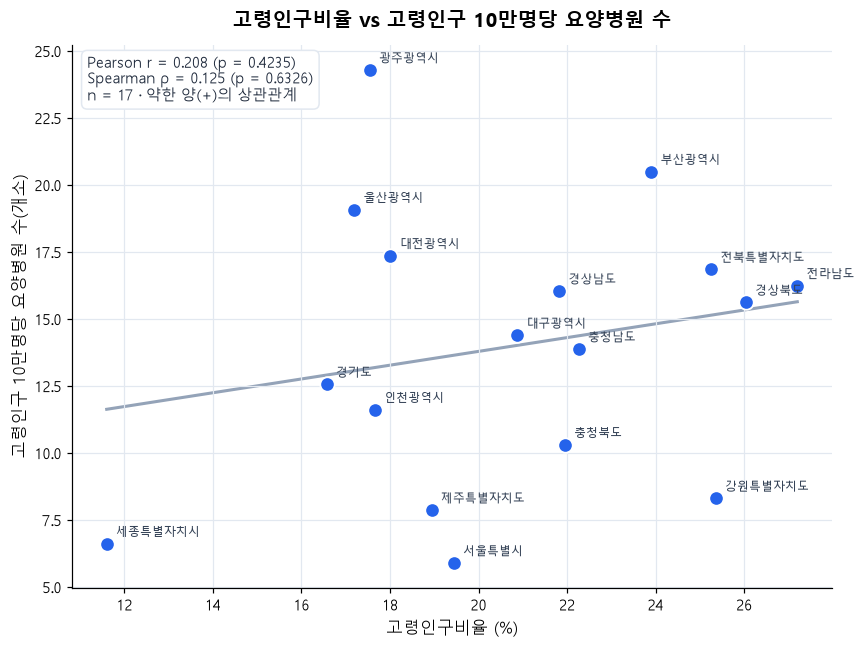

{'x': '고령인구비율',
 'y': '고령인구10만명당_요양병원수',
 'pearson_r': np.float64(0.208),
 'pearson_p': np.float64(0.4235),
 'spearman_r': np.float64(0.125),
 'spearman_p': np.float64(0.6326),
 'n': 17}

In [4]:
result_2 = scatter_with_corr(
    master,
    x_col="고령인구비율", y_col="고령인구10만명당_요양병원수",
    x_label="고령인구비율 (%)", y_label="고령인구 10만명당 요양병원 수(개소)",
    title="고령인구비율 vs 고령인구 10만명당 요양병원 수",
)
result_2

## 결과 요약

| 지표 쌍 | Pearson r | p-value | 해석 |
|---|---|---|---|
| 고령인구비율 vs 고령인구 10만명당 노인복지시설 수 | 약 0.51 | 0.037 (유의) | 중간 강도 양의 상관관계 |
| 고령인구비율 vs 고령인구 10만명당 요양병원 수 | 약 0.21 | 0.424 (유의하지 않음) | 뚜렷한 상관관계 없음 |

- **노인복지시설**(경로당·노인복지관 등 복지 인프라)은 고령화가 심한 지역일수록 인구 규모 대비
  공급이 더 많은 경향이 통계적으로 유의하게 나타난다(기존 "고령인구비율 vs 노인복지관 수" 결과와 방향 일치).
- **요양병원**(의료기관)은 고령화율과의 상관관계가 약하고 통계적으로 유의하지 않다. 즉 요양병원 입지는
  고령인구 비율보다 병상 수요·수익성·도시 접근성 등 다른 요인(인구 밀집도, 교통 등)의 영향을 더 크게
  받을 가능성을 시사한다 — 팀 공통 목표인 "고령화율 vs 병상수" 분석과 함께 교차 검증이 필요하다.
- 두 결과 모두 `data/aging/processed/correlation_result.csv`의 산출값과 일치한다(재현: `python -m src.aging.analysis.correlation`).